## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import KFold
!pip install pytorch-tabnet
!pip install entmax
from pytorch_tabnet.tab_model import TabNetRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import os
import torch
from sklearn.model_selection import RandomizedSearchCV
import joblib

!pip install xgboost -q
from xgboost import XGBRegressor

## REQUIRED FILES in /content/
salary.csv
  
    from https://www.kaggle.com/datasets/algozee/employee-salary-prediction-dataset
    (rename it to salary.csv)

best_tabnet_model.zip

ensemble_predictions.csv

tabnet_model_0.zip

tabnet_model_1.zip

tabnet_model_2.zip

tabnet_model_3.zip

tabnet_model_4.zip

best_xgb_model.joblib

X_meta_train.csv

    To prevent redundant training

## Load Dataset

In [2]:
df = pd.read_csv("salary.csv")

df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


## EDA

In [3]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


,0
job_title,0
experience_years,0
education_level,0
skills_count,0
industry,0
company_size,0
location,0
remote_work,0
certifications,0
salary,0


In [4]:
df.select_dtypes(include='object').columns

Index(['job_title', 'education_level', 'industry', 'company_size', 'location',
       'remote_work'],
      dtype='object')

In [5]:
num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print("\n Numerical Columns")
for col in num_cols:
    print("-", col)

print("\nCategorical Column")
for col in cat_cols:
    print("-", col)


 Numerical Columns
- experience_years
- skills_count
- certifications
- salary

Categorical Column
- job_title
- education_level
- industry
- company_size
- location
- remote_work


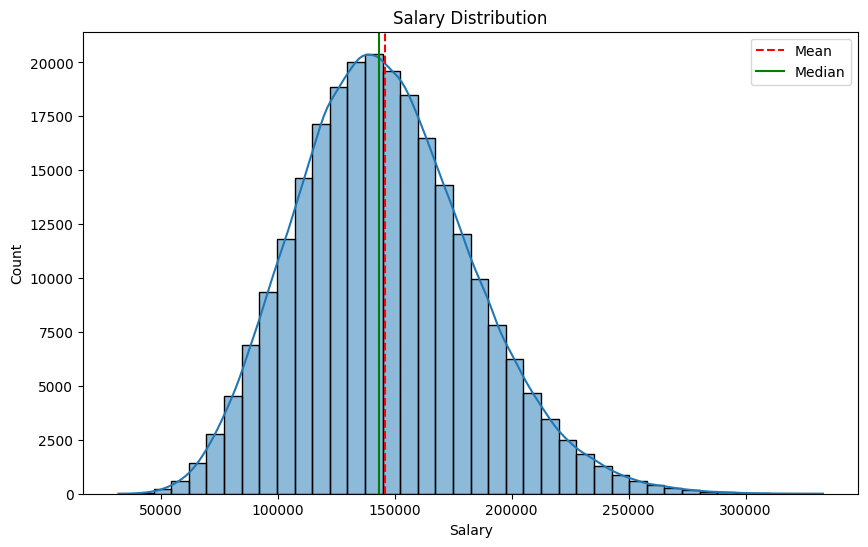

In [6]:
plt.figure(figsize=(10,6))
sns.histplot(df['salary'], bins=40, kde=True)

plt.axvline(df['salary'].mean(), color='red', linestyle='--', label='Mean')
plt.axvline(df['salary'].median(), color='green', linestyle='-', label='Median')

plt.title('Salary Distribution')
plt.xlabel('Salary')
plt.ylabel('Count')
plt.legend()
plt.show()

The salary distribution follows an approximately normal distribution with a slight right skew. The mean salary is slightly higher than the median, indicating the presence of high-salary outliers. Most salaries fall within the range of 100,000 to 80,000, while a small number of salaries exceed 250,000. The presence of outliers and skewness suggests that salary transformation or robust regression models may improve prediction performance.

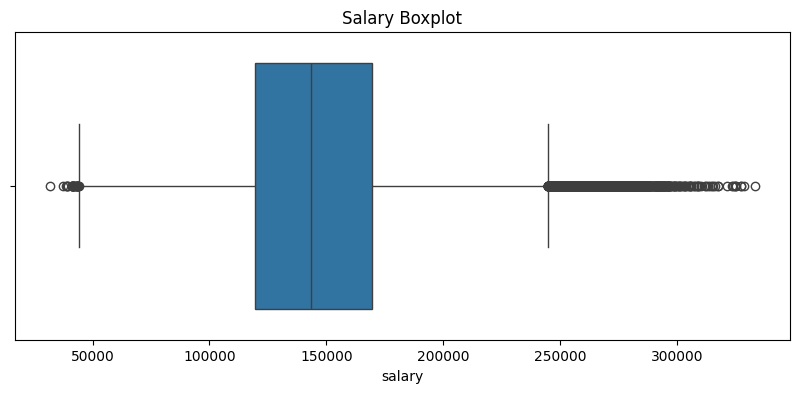

In [7]:
plt.figure(figsize=(10,4))
sns.boxplot(x=df['salary'])
plt.title('Salary Boxplot')
plt.show()

The salary boxplot shows that the median salary is approximately 145,000, with the interquartile range between 120,000 and 170,000, indicating that most employees earn within this range. The whiskers extend from approximately 50,000 to 250,000, representing the typical salary range. Several high-salary outliers above 250,000 are observed, indicating a small number of employees earning significantly higher salaries.

These outliers may affect regression model performance and may require transformation or outlier handling during preprocessing.

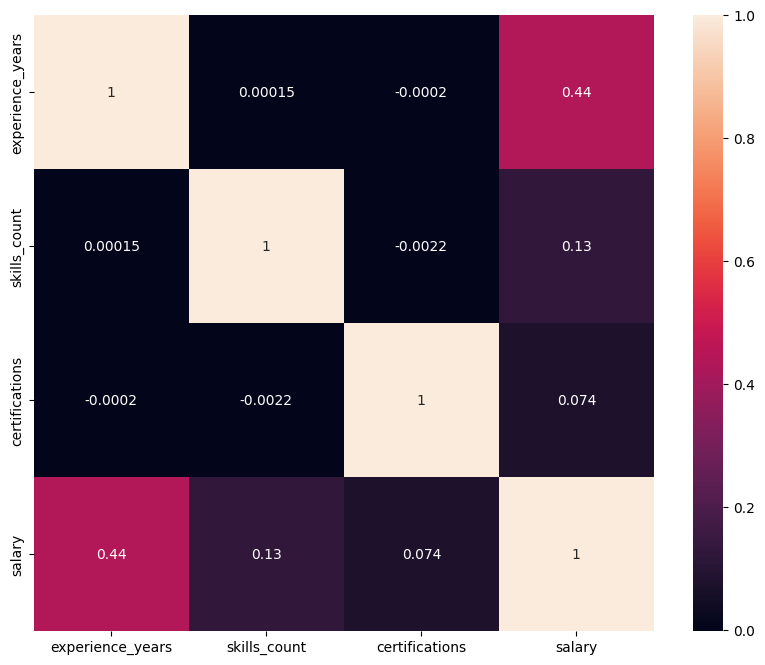

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

The correlation analysis shows that years of experience has the highest correlation with salary (0.44), indicating it is the most influential numerical feature. Skills count and certifications show weak correlations with salary (0.13 and 0.083 respectively), suggesting they may have limited predictive power individually. Additionally, there is very low correlation between the independent variables, indicating no multicollinearity issues. Overall, salary does not strongly depend on a single feature, suggesting that machine learning models capturing non-linear relationships may perform better for salary prediction.

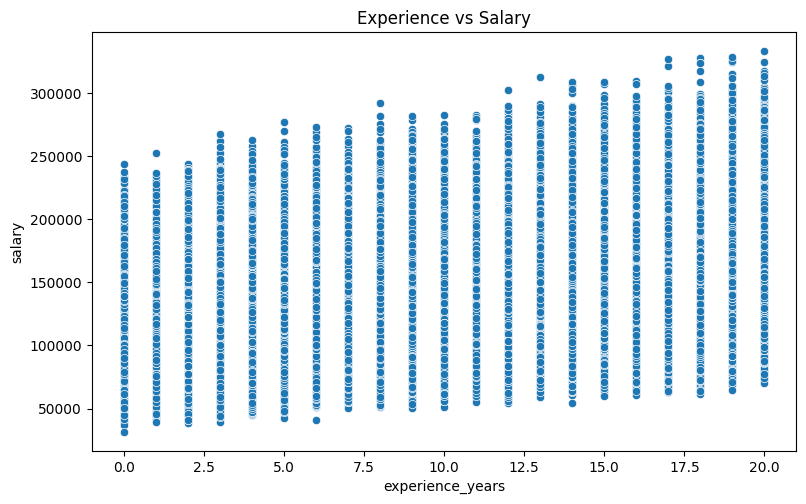

In [9]:
# 3 Experience vs Salary
plt.figure(figsize=(20, 25))
plt.subplot(4,2,3)
sns.scatterplot(x='experience_years', y='salary', data=df)
plt.title('Experience vs Salary')
plt.show()

The scatter plot of experience years versus salary shows a clear positive relationship, indicating that salary generally increases with years of experience.

But there is a wide spread of salaries for each experience level, suggesting that experience alone is not sufficient to predict salary accurately. This indicates that other factors such as job title, education level, industry, company size, and location likely play significant roles in determining salary.

The relationship between experience and salary appears moderately linear but with significant variability, suggesting that machine learning models using multiple features may provide better salary predictions than simple linear models.

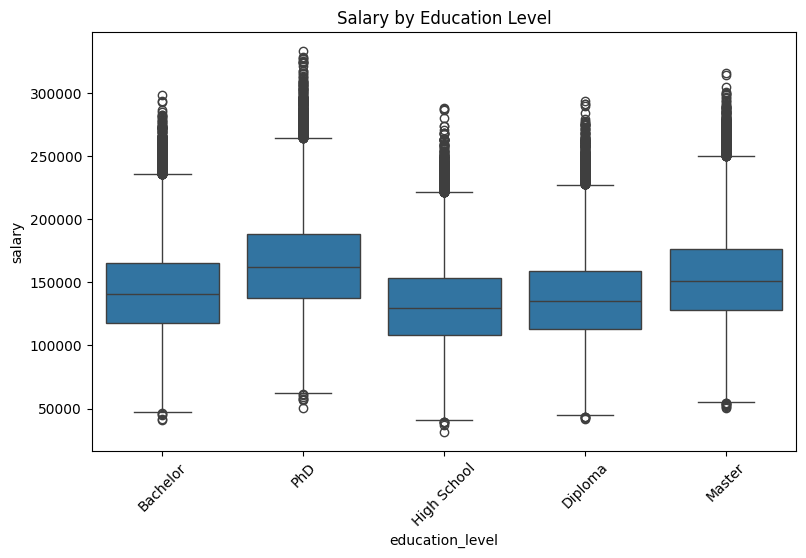

In [10]:
# 4 Salary by Education

plt.figure(figsize=(20, 25))
plt.subplot(4,2,4)
sns.boxplot(x='education_level', y='salary', data=df)
plt.title('Salary by Education Level')
plt.xticks(rotation=45)
plt.show()

The boxplot of salary by education level shows a clear trend where higher education levels are associated with higher median salaries. PhD holders earn the highest salaries, followed by Master’s degree holders, while individuals with high school education earn the lowest.

There is significant overlap in salary ranges across different education levels, indicating that education alone is not sufficient to determine salary. The wide spread within each category suggests that other factors such as experience, job role, and industry also play a significant role in salary determination.

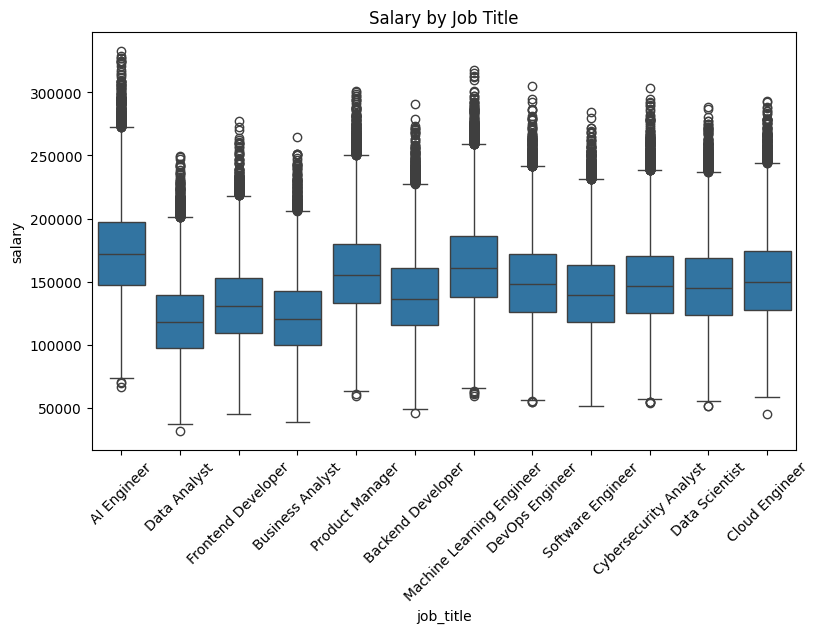

In [11]:
# 5 Salary by Job Title
plt.figure(figsize=(20, 25))
plt.subplot(4,2,5)
sns.boxplot(x='job_title', y='salary', data=df)
plt.title('Salary by Job Title')
plt.xticks(rotation=45)
plt.show()

The boxplot of salary by job title shows significant differences in salary distributions across different job roles. AI Engineers, Machine Learning Engineers, Product Managers, and Cloud Engineers tend to have higher median salaries, while Data Analysts and Business Analysts have lower median salaries. However, there is considerable overlap in salary ranges across job titles, indicating that other factors such as experience, education level, industry, and company size also influence salary.

This suggests that job title is an important feature for salary prediction but should be used alongside other features.

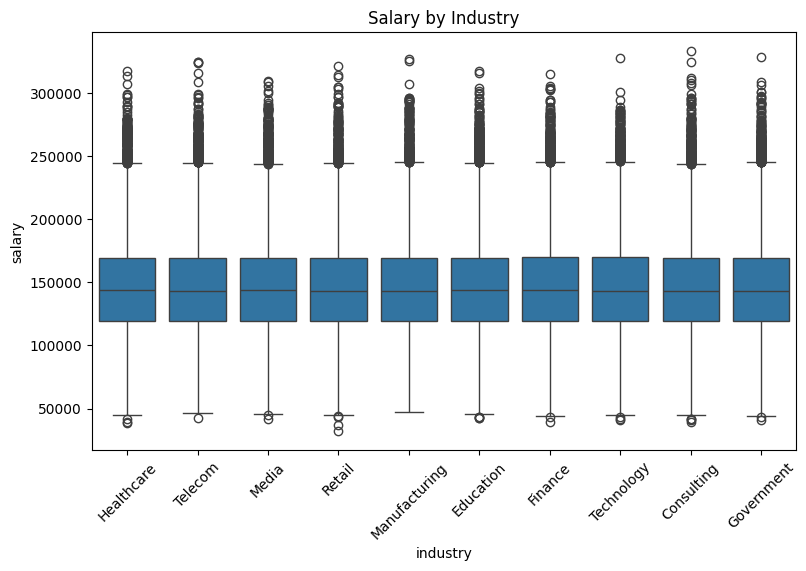

In [12]:
# 6 Salary by Industry
plt.figure(figsize=(20, 25))
plt.subplot(4,2,6)
sns.boxplot(x='industry', y='salary', data=df)
plt.title('Salary by Industry')
plt.xticks(rotation=45)
plt.show()

The boxplot of salary by job title shows significant differences in salary distributions across different job roles. AI Engineers, Machine Learning Engineers, Product Managers, and Cloud Engineers tend to have higher median salaries, while Data Analysts and Business Analysts have lower median salaries. However, there is considerable overlap in salary ranges across job titles, indicating that other factors such as experience, education level, industry, and company size also influence salary. This suggests that job title is an important feature for salary prediction but should be used alongside other features.

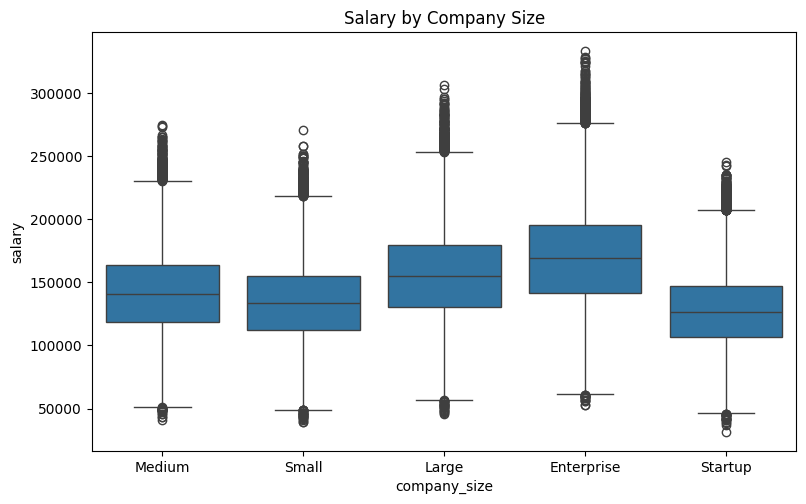

In [13]:
# 7 Salary by Company Size
plt.figure(figsize=(20, 25))
plt.subplot(4,2,7)
sns.boxplot(x='company_size', y='salary', data=df)
plt.title('Salary by Company Size')
plt.show()

The boxplot of salary by company size shows a clear trend where larger companies tend to offer higher salaries. Enterprise and large companies have higher median salaries compared to medium, small, and startup companies. Startups tend to offer the lowest median salaries.

This suggests that company size is an important factor influencing salary and should be included as a feature in salary prediction models.

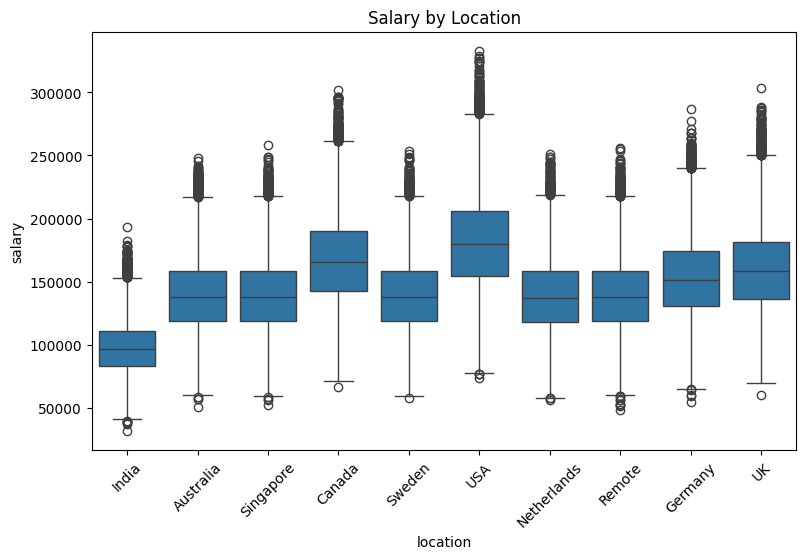

In [14]:
# 8 Salary by Location
plt.figure(figsize=(20, 25))
plt.subplot(4,2,8)
sns.boxplot(x='location', y='salary', data=df)
plt.title('Salary by Location')
plt.xticks(rotation=45)
plt.show()

The boxplot of salary by company size shows a clear trend where larger companies tend to offer higher salaries. Enterprise and large companies have higher median salaries compared to medium, small, and startup companies. Startups tend to offer the lowest median salaries. This suggests that company size is an important factor influencing salary and should be included as a feature in salary prediction models.

# Exploratory Data Analysis (EDA) Summary

## Salary Distribution
**Insight:** Salary distribution is slightly skewed with high-value outliers.


## Experience vs Salary
**Insight:** Experience is the most important numerical feature, but salary depends on multiple factors.


## Salary by Education Level
**Insight:** Education level influences salary but is not the only determining factor.


## Salary by Job Title
**Insight:** Job title is one of the most important features for salary prediction.


## Salary by Industry
**Insight:** Industry appears to have minimal impact on salary and may be a low-importance feature.


## Salary by Company Size
**Insight:** Company size is an important feature influencing salary.


## Correlation Analysis
**Insight:** Experience is the strongest numerical predictor of salary.


## Overall EDA Conclusions
1. Salary distribution is slightly right-skewed with outliers.
2. Experience years has the strongest correlation with salary.
3. Job title significantly influences salary.
4. Education level and company size moderately affect salary.
5. Industry has minimal effect on salary.
6. Salary prediction requires multiple features.


## Train Test Split with Preprocessing

In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, LabelEncoder

def preprocess_salary_data(
    df,
    target_col="salary",
    test_size=0.2,
    random_state=42
):
    """
    Splits data first, then applies separate preprocessing pipelines
    for Ridge and XGBoost/TabNet to prevent data leakage.
    """

    # 1. Load and initial cleaning
    df = df.dropna().copy()

    # 2. Split into Train and Test sets first
    # This ensures both versions (Ridge & XG) use the exact same base samples
    df_train, df_test = train_test_split(
        df, test_size=test_size, random_state=random_state
    )

    # 3. Define Column Groups
    num_cols = ['experience_years', 'skills_count', 'certifications']
    ord_cols = ['education_level', 'company_size']
    cat_cols = ['job_title', 'industry', 'location', 'remote_work']

    # 4. Prepare Targets (y)
    y_train = df_train[target_col].copy()
    y_test = df_test[target_col].copy()

    # 5. Numerical Scaling
    # Fit only on training data to avoid leaking test statistics

    scaler = StandardScaler()
    df_train[num_cols] = scaler.fit_transform(df_train[num_cols])
    df_test[num_cols] = scaler.transform(df_test[num_cols])

    # 6. Ordinal Encoding (education_level, company_size)
    edu_order = ["High School", "Diploma", "Bachelor", "Master", "PhD"]
    size_order = ["Startup", "Small", "Medium", "Large", "Enterprise"]

    ord_enc = OrdinalEncoder(categories=[edu_order, size_order])
    df_train[ord_cols] = ord_enc.fit_transform(df_train[ord_cols])
    df_test[ord_cols] = ord_enc.transform(df_test[ord_cols])

    # --- VERSION A: Ridge (One-Hot Encoding) ---
    # We use get_dummies and then align columns to handle missing categories in test
    # N-th coulumn of One-Hot Encoding for each original column is redunden.
    # Mathematically, if we know the value of N-1 binary columns, the N-th column is redundant information.
    # However, we set drop_first=Flase, because we want to compare ranking of feature importance laster with other models.
    X_train_ridge = pd.get_dummies(df_train.drop(columns=[target_col]), columns=cat_cols, drop_first=False)
    X_test_ridge = pd.get_dummies(df_test.drop(columns=[target_col]), columns=cat_cols, drop_first=False)

    # Align X_test_ridge to have the same columns as X_train_ridge
    X_test_ridge = X_test_ridge.reindex(columns=X_train_ridge.columns, fill_value=0)

    # --- VERSION B: XGBoost/TabNet (Label Encoding) ---
    X_train_xgtab = df_train.drop(columns=[target_col]).copy()
    X_test_xgtab = df_test.drop(columns=[target_col]).copy()

    label_encoders = {}
    for col in cat_cols:
        le = LabelEncoder()
        # Fit on train, transform both
        X_train_xgtab[col] = le.fit_transform(X_train_xgtab[col])

        label_encoders[col] = le

        # Mapping unseen labels in test to a default or handling errors
        # (LabelEncoder requires all test labels to exist in train)
        X_test_xgtab[col] = X_test_xgtab[col].map(lambda s: s if s in le.classes_ else le.classes_[0])
        X_test_xgtab[col] = le.transform(X_test_xgtab[col])

    return (
        X_train_ridge, X_test_ridge,
        X_train_xgtab, X_test_xgtab,
        y_train, y_test,
        # for demo
        scaler, ord_enc, label_encoders
    )

In [16]:
X_train_ridge, X_test_ridge, X_train_xgtab, X_test_xgtab, y_train, y_test, scaler, ord_enc, label_encoders = preprocess_salary_data(df)

In [17]:
X_train_ridge.columns

Index(['experience_years', 'education_level', 'skills_count', 'company_size',
       'certifications', 'job_title_AI Engineer',
       'job_title_Backend Developer', 'job_title_Business Analyst',
       'job_title_Cloud Engineer', 'job_title_Cybersecurity Analyst',
       'job_title_Data Analyst', 'job_title_Data Scientist',
       'job_title_DevOps Engineer', 'job_title_Frontend Developer',
       'job_title_Machine Learning Engineer', 'job_title_Product Manager',
       'job_title_Software Engineer', 'industry_Consulting',
       'industry_Education', 'industry_Finance', 'industry_Government',
       'industry_Healthcare', 'industry_Manufacturing', 'industry_Media',
       'industry_Retail', 'industry_Technology', 'industry_Telecom',
       'location_Australia', 'location_Canada', 'location_Germany',
       'location_India', 'location_Netherlands', 'location_Remote',
       'location_Singapore', 'location_Sweden', 'location_UK', 'location_USA',
       'remote_work_Hybrid', 'remote_wo

In [18]:
X_train_xgtab.columns

Index(['job_title', 'experience_years', 'education_level', 'skills_count',
       'industry', 'company_size', 'location', 'remote_work',
       'certifications'],
      dtype='object')

In [19]:
X_train_xgtab.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications
75381,9,-0.991110,1.0,0.730405,8,2.0,3,2,1.467841
65569,1,-1.486151,4.0,-0.730392,0,3.0,7,2,-0.874320
163473,1,0.989057,0.0,-1.278191,5,2.0,1,1,-0.874320
90518,5,-0.991110,0.0,1.460804,2,0.0,8,0,0.882301
138866,1,-0.496068,1.0,-0.365193,7,2.0,2,1,-1.459860


## Ridge (Use X_train_ridge and X_test_ridge, y_train, y_test)

In [20]:
from sklearn.model_selection import KFold
import numpy as np

def run_ridge(X_train, y_train, X_test, alpha=1.0):
    """Run Ridge with 5-fold OOF and test predictions"""
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    oof_predictions = np.zeros(len(X_train))
    test_predictions = np.zeros(len(X_test))

    for train_idx, val_idx in kf.split(X_train):
        X_tr = X_train.iloc[train_idx]
        X_val = X_train.iloc[val_idx]
        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]

        model = Ridge(alpha=alpha, random_state=42)
        model.fit(X_tr, y_tr)

        oof_predictions[val_idx] = model.predict(X_val)
        test_predictions += model.predict(X_test) / kf.n_splits   # average

    return oof_predictions, test_predictions

In [21]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

alphas = [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
best_alpha = None
best_rmse = float("inf")

print("Tuning Ridge regularization (alpha)...\n")

for alpha in alphas:
    ridge_oof_temp, _ = run_ridge(X_train_ridge, y_train, X_test_ridge, alpha=alpha)
    rmse = np.sqrt(mean_squared_error(y_train, ridge_oof_temp))
    r2 = r2_score(y_train, ridge_oof_temp)

    print(f"Alpha: {alpha:8.2f} | OOF RMSE: {rmse:8.2f} | OOF R²: {r2:.4f}")

    if rmse < best_rmse:
        best_rmse = rmse
        best_alpha = alpha

print(f"\nBest alpha found: {best_alpha}")

Tuning Ridge regularization (alpha)...

Alpha:     0.01 | OOF RMSE:  7904.04 | OOF R²: 0.9554
Alpha:     0.10 | OOF RMSE:  7904.04 | OOF R²: 0.9554
Alpha:     1.00 | OOF RMSE:  7904.04 | OOF R²: 0.9554
Alpha:    10.00 | OOF RMSE:  7904.06 | OOF R²: 0.9554
Alpha:   100.00 | OOF RMSE:  7905.96 | OOF R²: 0.9554
Alpha:  1000.00 | OOF RMSE:  8073.35 | OOF R²: 0.9535

Best alpha found: 0.1


In [22]:
# Final Ridge model
ridge_oof, ridge_test = run_ridge(
    X_train_ridge, y_train, X_test_ridge, alpha=best_alpha
)

print(f"Final Ridge Results (alpha = {best_alpha})")
print(f"OOF  R²  : {r2_score(y_train, ridge_oof):.4f}")
print(f"Test R²  : {r2_score(y_test, ridge_test):.4f}")
print(f"OOF  RMSE: {np.sqrt(mean_squared_error(y_train, ridge_oof)):.2f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, ridge_test)):.2f}")

Final Ridge Results (alpha = 0.1)
OOF  R²  : 0.9554
Test R²  : 0.9554
OOF  RMSE: 7904.04
Test RMSE: 7875.30


In [23]:
print("Ridge (run_ridge function) OOF R2:", r2_score(y_train, ridge_oof))
print("Ridge (run_ridge function) Test R2:", r2_score(y_test, ridge_test))

print("Ridge (run_ridge function) OOF MAE:", mean_absolute_error(y_train, ridge_oof))
print("Ridge (run_ridge function) Test MAE:", mean_absolute_error(y_test, ridge_test))

Ridge (run_ridge function) OOF R2: 0.9554305843511716
Ridge (run_ridge function) Test R2: 0.9553766192665362
Ridge (run_ridge function) OOF MAE: 6078.2957178589895
Ridge (run_ridge function) Test MAE: 6059.219857685847


###Ridge Parameter Tuning using GridSearchCV

In [24]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge

param_grid_ridge = {
    "alpha": [0.0001, 0.001, 0.01, 0.1, 1, 10, 50, 100, 500, 1000]
}

grid_ridge = GridSearchCV(
    Ridge(),
    param_grid_ridge,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

grid_ridge.fit(X_train_ridge, y_train)

best_alpha_ridge = grid_ridge.best_params_["alpha"]

print("Best alpha:", best_alpha)

Best alpha: 0.1


In [25]:
ridge_oof, ridge_test = run_ridge(
    X_train_ridge, y_train, X_test_ridge, alpha=best_alpha_ridge
)

### ridge Evaluations (RMSE and $R^2$)

In [54]:
# OOF Evaluation (training performance)
r2_oof = r2_score(y_train, ridge_oof)
rmse_oof = np.sqrt(mean_squared_error(y_train, ridge_oof))

# Test Evaluation
r2_ridge = r2_score(y_test, ridge_test)
rmse_ridge = np.sqrt(mean_squared_error(y_test, ridge_test))

print("OOF R2:", r2_oof)
print("OOF RMSE:", rmse_oof)

print("Test R2:", r2_ridge)
print("Test RMSE:", rmse_ridge)

OOF R2: 0.9554305843511716
OOF RMSE: 7904.041444010518
Test R2: 0.9553766192665362
Test RMSE: 7875.30406403085


###Prediction Plot

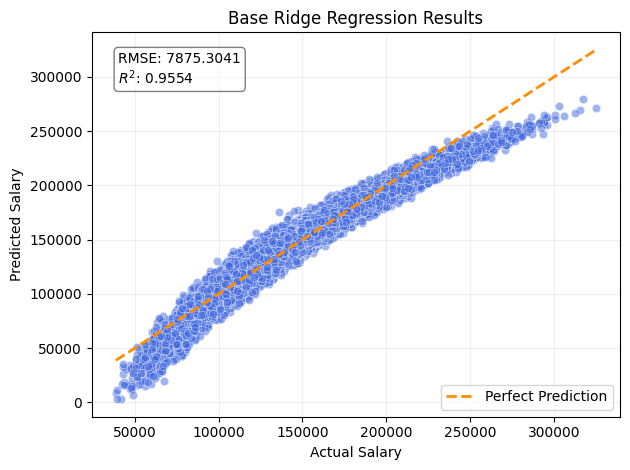

In [28]:
plt.figure()

# Scatter plot for Actual vs Predicted
sns.scatterplot(
    x=np.array(y_test).flatten(),
    y=np.array(ridge_test).flatten(),
    alpha=0.5,
    color='royalblue'
)

# Perfect Prediction Line (y=x)
line_coords = [y_test.min(), y_test.max()]
plt.plot(line_coords, line_coords, color='darkorange', linestyle='--', lw=2, label='Perfect Prediction')

# Add metrics info box to the plot
stats_text = f'RMSE: {rmse_ridge:.4f}\n$R^2$: {r2_ridge:.4f}'
plt.text(0.05, 0.95, stats_text,
         transform=plt.gca().transAxes,
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

plt.title('Base Ridge Regression Results')
plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.legend()
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

###Feature Importance

In [29]:
# Train final Ridge model to extract coefficients
ridge_model = Ridge(alpha=best_alpha_ridge, random_state=42)
ridge_model.fit(X_train_ridge, y_train)

feature_names = X_train_ridge.columns
coef = ridge_model.coef_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coef
})

importance_df["abs_coef"] = importance_df["Coefficient"].abs()
importance_df = importance_df.sort_values(by="abs_coef", ascending=False)

importance_df.head(10)

,Feature,Coefficient,abs_coef
30,location_India,-48161.761437,48161.761437
36,location_USA,35681.029156,35681.029156
5,job_title_AI Engineer,28003.720684,28003.720684
10,job_title_Data Analyst,-25753.220731,25753.220731
7,job_title_Business Analyst,-23467.343066,23467.343066
28,location_Canada,21654.446671,21654.446671
14,job_title_Machine Learning Engineer,17354.907789,17354.907789
0,experience_years,16354.567568,16354.567568
35,location_UK,14653.323701,14653.323701
13,job_title_Frontend Developer,-12826.607241,12826.607241


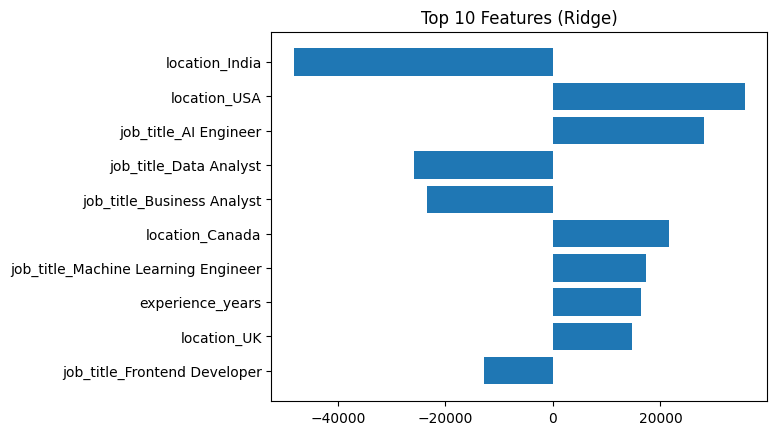

In [30]:
plt.figure()
plt.barh(importance_df["Feature"][:10], importance_df["Coefficient"][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Features (Ridge)")
plt.show()

In [31]:
def plot_aggregated_ridge_importance(model, ohe_columns, original_features):
    # Extract absolute values of coefficients
    # The magnitude represents the 'strength' of the feature's influence
    abs_coefs = np.abs(model.coef_.flatten())

    # Map OHE sub-columns back to parent features
    importance_dict = {feat: 0.0 for feat in original_features}

    for col_name, coef_val in zip(ohe_columns, abs_coefs):
        matched = False
        for parent in original_features:
            if col_name.startswith(parent):
                importance_dict[parent] += coef_val
                matched = True
                break

        # Handle numerical/ordinal columns that weren't OHE'd
        if not matched:
            importance_dict[col_name] = importance_dict.get(col_name, 0.0) + coef_val

    # Create DataFrame and Sort
    importance_df = pd.DataFrame({
        'Feature': importance_dict.keys(),
        'Importance': importance_dict.values()
    }).sort_values(by='Importance', ascending=False)

    # Plotting
    plt.figure()
    sns.barplot(
        data=importance_df,
        x='Importance',
        y='Feature',
    )

    plt.title('Ridge Regression: Aggregated Feature Importance')
    plt.xlabel('Sum of Absolute Coefficients',)
    plt.ylabel('Original Feature Category')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

orginal features:  ['job_title', 'experience_years', 'education_level', 'skills_count', 'industry', 'company_size', 'location', 'remote_work', 'certifications']


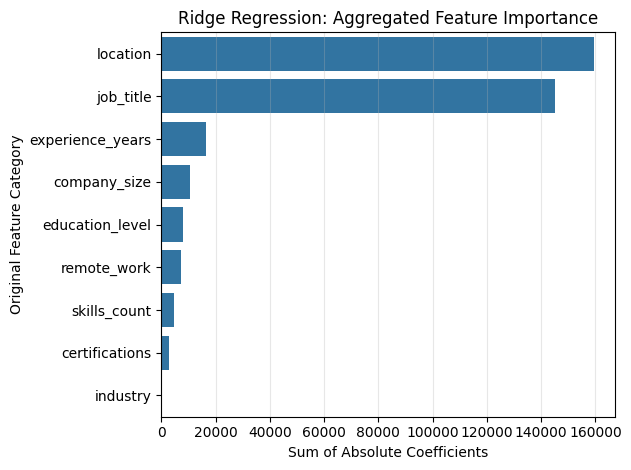

In [32]:
original_features = X_train_xgtab.columns.tolist()
print(f"orginal features: ", original_features)

plot_aggregated_ridge_importance(ridge_model, X_train_ridge.columns, original_features)

## XGBoost (Use X_train_xgtab, X_test_xgtab, y_train, y_test)

In [33]:
if os.path.exists("/content/best_xgb_model.joblib"):
  best_xgb = joblib.load("/content/best_xgb_model.joblib")

  # prediction
  best_preds_xgb = best_xgb.predict(X_test_xgtab)
  print("XGBoost model loaded and prediction successful!")

  # evaluation metrics
  xgb_rmse = np.sqrt(mean_squared_error(y_test, best_preds_xgb))
  xgb_r2 = r2_score(y_test, best_preds_xgb)
  print(f"R2 Score: {xgb_r2:.4f}")
  print(f"RMSE: {xgb_rmse:.2f}")
else:
  param_grid_xgb = {
      'n_estimators': [200, 300],
      'max_depth': [4, 6, 8],
      'learning_rate': [0.05, 0.1],
      'subsample': [0.8, 1.0],
      'colsample_bytree': [0.8, 1.0]
  }

  xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

  grid_search_xgb = GridSearchCV(
      estimator=xgb,
      param_grid=param_grid_xgb,
      cv=3,
      scoring='r2',
      n_jobs=-1,
      verbose=1
  )

  grid_search_xgb.fit(X_train_xgtab, y_train)

  best_xgb = grid_search_xgb.best_estimator_

  best_preds_xgb = best_xgb.predict(X_test_xgtab)

  print("Best Parameters:", grid_search_xgb.best_params_)
  print("Best CV Score:", grid_search_xgb.best_score_)

  print("Tuned XGBoost Results")
  xgb_rmse = np.sqrt(mean_squared_error(y_test, best_preds_xgb))
  xgb_r2 = r2_score(y_test, best_preds_xgb)
  print(f"R2 Score: {xgb_r2:.4f}")
  # print(f"MAE: {mean_absolute_error(y_test, best_preds_xgb):.2f}")
  print(f"RMSE: {xgb_rmse:.2f}")

  # save model
  joblib.dump(best_xgb, '/content/best_xgb_model.joblib')

XGBoost model loaded and prediction successful!
R2 Score: 0.9806
RMSE: 5191.45


### XGBoost Evaluation


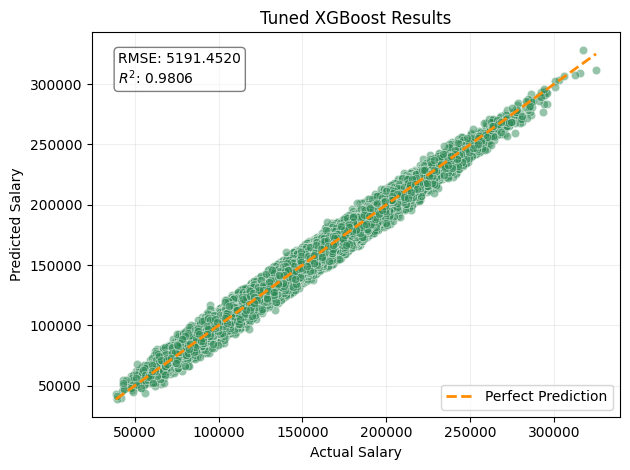

In [34]:
plt.figure()

# Scatter plot for Actual vs Predicted
sns.scatterplot(
    x=np.array(y_test).flatten(),
    y=np.array(best_preds_xgb).flatten(),
    alpha=0.5,
    color='seagreen'
)

# Perfect Prediction Line (y=x)
line_coords = [y_test.min(), y_test.max()]
plt.plot(line_coords, line_coords, color='darkorange', linestyle='--', lw=2, label='Perfect Prediction')

# Add metrics info box to the plot
stats_text = f'RMSE: {xgb_rmse:.4f}\n$R^2$: {xgb_r2:.4f}'
plt.text(0.05, 0.95, stats_text,
         transform=plt.gca().transAxes,
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

plt.title('Tuned XGBoost Results')
plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.legend()
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

In [35]:
# Feature importance
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X_train_xgtab.columns,
    'Importance': best_xgb.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importance.head(10))

            Feature  Importance
5      company_size    0.254551
6          location    0.245199
1  experience_years    0.187255
2   education_level    0.152132
0         job_title    0.107118
3      skills_count    0.022035
7       remote_work    0.018560
8    certifications    0.012903
4          industry    0.000246


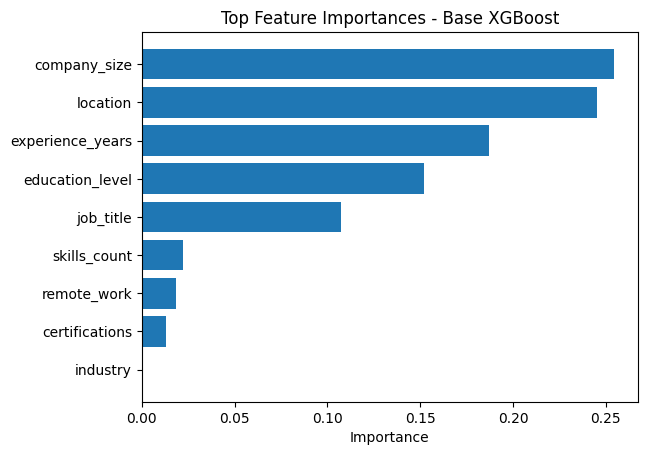

In [36]:
# Plot important features
plt.figure()
plt.barh(feature_importance['Feature'].head(10)[::-1],
         feature_importance['Importance'].head(10)[::-1])
plt.xlabel("Importance")
plt.title("Top Feature Importances - Base XGBoost")
plt.show()

## Tabnet(Use X_train_xgtab, X_test_xgtab, y_train, y_test)

In [37]:
# Convert features to float32 NumPy arrays
X_train_np = X_train_xgtab.values.astype(np.float32) if hasattr(X_train_xgtab, 'values') else X_train_xgtab.astype(np.float32)
X_test_np = X_test_xgtab.values.astype(np.float32) if hasattr(X_test_xgtab, 'values') else X_test_xgtab.astype(np.float32)

# Convert targets to 2D float32 NumPy arrays (TabNet requires (N, 1) shape)
y_train_np = y_train.values.reshape(-1, 1).astype(np.float32) if hasattr(y_train, 'values') else y_train.reshape(-1, 1).astype(np.float32)
y_test_np = y_test.values.reshape(-1, 1).astype(np.float32) if hasattr(y_test, 'values') else y_test.reshape(-1, 1).astype(np.float32)

In [38]:
if os.path.exists("/content/best_tabnet_model.zip"):
  # Initialize a new model object
  best_tabnet = TabNetRegressor()

  # Load the saved weights and parameters
  # You must provide the full path to the .zip file
  best_tabnet.load_model("/content/best_tabnet_model.zip")

  # Verify by making a prediction
  y_pred_tabnet = best_tabnet.predict(X_test_np)
  print("Model loaded and prediction successful!")

else:
  tabnet_model = TabNetRegressor(
    device_name='cuda',
    optimizer_fn=torch.optim.Adam,
    verbose=0
  )
  # Use a list of dicts to ensure n_d and n_a stay equal
  param_dist_tab = [
      {
          'n_d': [size],
          'n_a': [size],
          'n_steps': [3, 5],
          'gamma': [1.3, 1.5],
          'lambda_sparse': [1e-3, 1e-2],
          'mask_type': ['sparsemax', 'entmax'],
          'optimizer_params': [
              dict(lr=5e-2), # High: To escape local minima/flat regions
              dict(lr=2e-2), # Standard: Original TabNet paper default
              dict(lr=1e-2), # Moderate: Good for noisy data
              dict(lr=5e-3), # Conservative: Better for small datasets
              dict(lr=1e-3)  # Fine-tuning: For final convergence
          ]
      } for size in [16, 32, 64]
  ]

  scoring_metrics = {
      'rmse': 'neg_root_mean_squared_error',
      'r2': 'r2'
  }

  # Setup RandomizedSearchCV
  random_search_tabnet = RandomizedSearchCV(
      estimator=tabnet_model,
      param_distributions=param_dist_tab,
      n_iter=30,
      cv=3,
      scoring=scoring_metrics,
      refit='rmse',
      verbose=2,
      n_jobs=1,
      random_state=42
  )

  print("Starting Randomized Search...")
  random_search_tabnet.fit(
      X_train_np, y_train_np,
      eval_set=[(X_test_np, y_test_np)],
      patience=10,
      max_epochs=100
  )

  print(f"Best Parameters: {random_search_tabnet.best_params_}")
  print(f"Best Score (RMSE): {-random_search_tabnet.best_score_}")

  # Get the best model and predict
  best_tabnet = random_search_tabnet.best_estimator_
  y_pred_tabnet = best_tabnet.predict(X_test_np)

  # Save the model
  # Best Parameters: {'optimizer_params': {'lr': 0.01}, 'n_steps': 3, 'n_d': 64, 'n_a': 64, 'mask_type': 'entmax', 'lambda_sparse': 0.001, 'gamma': 1.3}
  # Best Score (RMSE): 5374.516438802083
  best_tabnet.save_model("/content/best_tabnet_model")

  print(f"Model saved successfully to best_tabnet_model.zip")

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


Model loaded and prediction successful!


Evaluation

Test RMSE: 5232.6569
Test R-squared (R2): 0.9803


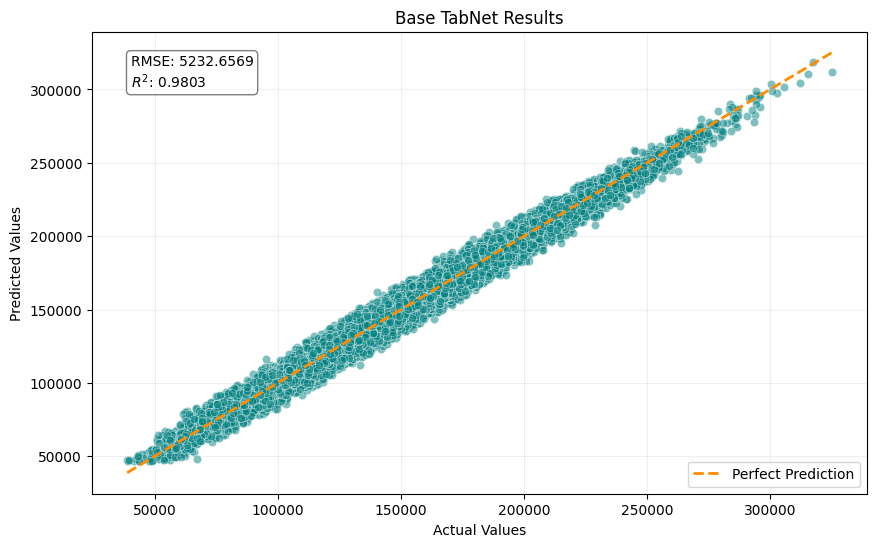

In [39]:
# Calculate Evaluation Metrics (RMSE, R-squared)
mse = mean_squared_error(y_test_np, y_pred_tabnet)
rmse = np.sqrt(mse)

# R-squared (Coefficient of Determination)
r2 = r2_score(y_test_np, y_pred_tabnet)

print(f"Test RMSE: {rmse:.4f}")
print(f"Test R-squared (R2): {r2:.4f}")

# Visualization with Metrics
plt.figure(figsize=(10, 6))

# Scatter plot for Actual vs Predicted
sns.scatterplot(x=y_test_np.flatten(), y=y_pred_tabnet.flatten(), alpha=0.5, color='teal')

# Perfect Prediction Line (y=x)
line_coords = [y_test_np.min(), y_test_np.max()]
plt.plot(line_coords, line_coords, color='darkorange', linestyle='--', lw=2, label='Perfect Prediction')

# Add metrics info to the plot
plt.text(0.05, 0.95, f'RMSE: {rmse:.4f}\n$R^2$: {r2:.4f}',
         transform=plt.gca().transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

plt.title('Base TabNet Results')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

## Deep Ensemble with Tabnet (Use X_train_xgtab, X_test_xgtab, y_train, y_test)

In [40]:
n_ensemble = 5
if os.path.exists("/content/ensemble_predictions.csv"):
  print("Loading ensemble_predictions.csv")
  pred_ensemble_df = pd.read_csv("/content/ensemble_predictions.csv")
  predictions_ensemble = pred_ensemble_df['salary_ensemble'].values
  print("Loading ensemble models...")
  ensemble_models = []
  for i in range(n_ensemble):
      # Initialize a blank model
      model = TabNetRegressor()

      # Load the specific zip file
      model.load_model(os.path.join("/content/", f"tabnet_model_{i}.zip"))

      ensemble_models.append(model)

  ensemble_train_predictions = []
  for i, model in enumerate(ensemble_models):
    train_preds = model.predict(X_train_np)
    ensemble_train_predictions.append(train_preds)
    print(f"Model {i+1} training predictions complete.")

  tabnet_train_preds = np.mean(ensemble_train_predictions, axis=0).flatten()
else:
  # best_params_tab = random_search_tabnet.best_params_
  best_params_tab = {'optimizer_params': {'lr': 0.01}, 'n_steps': 3, 'n_d': 64, 'n_a': 64, 'mask_type': 'entmax', 'lambda_sparse': 0.001, 'gamma': 1.3}
  print("best_params: ", best_params_tab)
  n_ensemble = 5
  ensemble_models = []
  ensemble_train_predictions = []
  ensemble_predictions = []

  print(f"Training Deep Ensemble with {n_ensemble} models...")

  for i in range(n_ensemble):
      print(f"--- Training Model {i+1}/{n_ensemble} ---")
      # Ensure diversity by assigning a different seed every time a model is generated.
      model = TabNetRegressor(**best_params_tab, seed=i, verbose=0)

      # Train
      model.fit(
          X_train_np, y_train_np,
          eval_set=[(X_test_np, y_test_np)],
          patience=10,
          max_epochs=100
      )

      # Prediction
      preds = model.predict(X_test_np)
      ensemble_predictions.append(preds)
      ensemble_models.append(model)

  # ensemble_train_predictions
  for i, model in enumerate(ensemble_models):
    train_preds = model.predict(X_train_np)
    ensemble_train_predictions.append(train_preds)
    print(f"Model {i+1} training predictions complete.")

  # Ensemble: take mean of each prediction
  predictions_ensemble = np.mean(ensemble_predictions, axis=0)
  tabnet_train_preds = np.mean(ensemble_train_predictions, axis=0).flatten()

  # Evaluation: RMSE and R2
  rmse_ensemble = np.sqrt(mean_squared_error(y_test_np, predictions_ensemble))
  r2_ensemble = r2_score(y_test_np, predictions_ensemble)

  print(f"\n[Ensemble Result] RMSE: {rmse_ensemble:.4f}, R2: {r2_ensemble:.4f}")

  # save trained models
  for i, model in enumerate(ensemble_models):
      # This will create files like: tabnet_model_0.zip, tabnet_model_1.zip, etc.
      model.save_model(os.path.join("/content/", f"tabnet_model_{i}"))

  # Convert the NumPy array to a Pandas DataFrame
  df_predictions = pd.DataFrame(predictions_ensemble, columns=['salary_ensemble'])

  # Define the CSV path
  csv_path = os.path.join("/content/", "ensemble_predictions.csv")

  # Save to CSV
  # index=False prevents pandas from adding an extra column for the row numbers
  df_predictions.to_csv(csv_path, index=False)

  print(f"Predictions successfully saved to: {csv_path}")

Loading ensemble_predictions.csv
Loading ensemble models...


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


Model 1 training predictions complete.
Model 2 training predictions complete.
Model 3 training predictions complete.
Model 4 training predictions complete.
Model 5 training predictions complete.


[Final Ensemble] Test RMSE: 5176.5540
[Final Ensemble] Test R-squared (R2): 0.9807


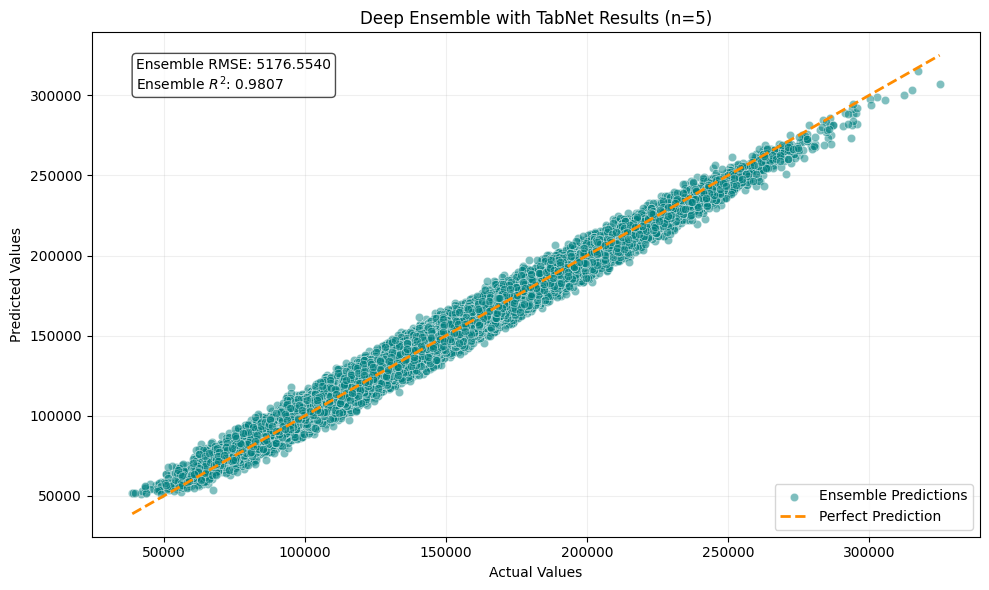

In [41]:
rmse_recalculated = np.sqrt(mean_squared_error(y_test_np, predictions_ensemble))
r2_recalculated = r2_score(y_test_np, predictions_ensemble)
print(f"[Final Ensemble] Test RMSE: {rmse_recalculated:.4f}")
print(f"[Final Ensemble] Test R-squared (R2): {r2_recalculated:.4f}")

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=y_test_np.flatten(),
    y=predictions_ensemble.flatten(),
    alpha=0.5,
    color='teal',
    label='Ensemble Predictions'
)

# Perfect Prediction Line (y=x)
line_coords = [y_test_np.min(), y_test_np.max()]
plt.plot(line_coords, line_coords, color='darkorange', linestyle='--', lw=2, label='Perfect Prediction')

stats_text = f'Ensemble RMSE: {rmse_recalculated:.4f}\nEnsemble $R^2$: {r2_recalculated:.4f}'
plt.text(0.05, 0.95, stats_text,
         transform=plt.gca().transAxes,
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

plt.title(f'Deep Ensemble with TabNet Results (n={n_ensemble})')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

Re-calculating importance for the ensemble...


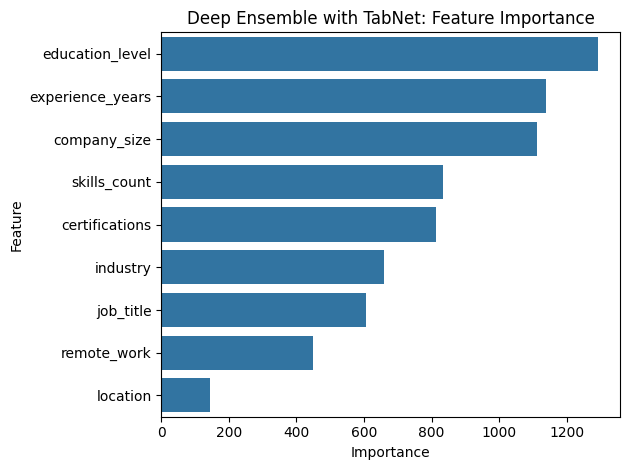

In [42]:
# Assuming you have your feature names from your X_train dataframe
feature_names_tab = X_train_xgtab.columns.tolist()

# Initialize a list to hold the importance arrays
ensemble_importances = []

print("Re-calculating importance for the ensemble...")

for i, model in enumerate(ensemble_models):
    # 'explain' returns: (explainability_matrix, masks)
    # The matrix has shape (n_samples, n_features)
    expl_matrix, _ = model.explain(X_test_np)

    # Global importance for this model is the mean across all samples
    model_importance = np.mean(expl_matrix, axis=0)
    ensemble_importances.append(model_importance)

# Average across all 5 models for the Final Ensemble Importance
final_importance_tab = np.mean(ensemble_importances, axis=0)

# Create DataFrame
importance_df_tab = pd.DataFrame({
    'Feature': feature_names_tab,
    'Importance': final_importance_tab
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure()
sns.barplot(x='Importance', y='Feature', data=importance_df_tab.head(10))
plt.title('Deep Ensemble with TabNet: Feature Importance')
plt.tight_layout()
plt.show()

## Stacking

In [43]:
if os.path.exists("/content/X_meta_train.csv"):
  X_meta_train_df = pd.read_csv("/content/X_meta_train.csv")
else:
  # Configuration
  n_splits = 10
  n_ensemble = 5  # Number of models in the Deep Ensemble per fold
  kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

  # Initialize OOF arrays
  oof_ridge = np.zeros(len(y_train))
  oof_xgb = np.zeros(len(y_train))
  oof_tabnet = np.zeros(len(y_train))

  print(f"Starting OOF generation with {n_ensemble}-model TabNet Ensemble per fold...")

  for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_xgtab)):
      print(f"\n--- Processing Fold {fold+1}/{n_splits} ---")

      # Data splitting
      X_tr_r, X_val_r = X_train_ridge.iloc[train_idx], X_train_ridge.iloc[val_idx]
      X_tr_x, X_val_x = X_train_xgtab.iloc[train_idx], X_train_xgtab.iloc[val_idx]
      X_tr_np, X_val_np = X_train_np[train_idx], X_train_np[val_idx]

      y_tr_fold = y_train.iloc[train_idx]
      y_val_fold = y_train.iloc[val_idx]

      # --- 1. Ridge ---
      m1 = Ridge(alpha=best_alpha)
      m1.fit(X_tr_r, y_tr_fold)
      oof_ridge[val_idx] = m1.predict(X_val_r).flatten()

      # --- 2. XGBoost ---
      m2 = XGBRegressor(**best_xgb.get_params())
      m2.fit(X_tr_x, y_tr_fold)
      oof_xgb[val_idx] = m2.predict(X_val_x).flatten()

      # --- 3. TabNet Deep Ensemble ---
      fold_ensemble_preds = []
      tabnet_params = best_tabnet.get_params()

      for i in range(n_ensemble):
          print(f"Ensemble {i} training")
          # Create a new model with a unique seed for diversity
          tabnet_params['seed'] = i
          m3 = TabNetRegressor(**tabnet_params)

          m3.fit(
              X_train=X_tr_np, y_train=y_tr_fold.values.reshape(-1, 1),
              eval_set=[(X_val_np, y_val_fold.values.reshape(-1, 1))],
              patience=10, max_epochs=100
          )

          # Predict on validation fold
          fold_ensemble_preds.append(m3.predict(X_val_np).flatten())

          # Memory Management
          del m3
          torch.cuda.empty_cache()

      # Average the ensemble predictions for this fold
      oof_tabnet[val_idx] = np.mean(fold_ensemble_preds, axis=0)
      print(f"Fold {fold+1} complete (Ridge + XGB + {n_ensemble} TabNets)")

  # --- STEP 1: Create Meta-Feature Matrix ---
  X_meta_train = np.column_stack([oof_ridge, oof_xgb, oof_tabnet])
  X_meta_train_df = pd.DataFrame(X_meta_train, columns=['Ridge_Pred', 'XGBoost_Pred', 'TabNet_Ensemble_Pred'])

  # save
  X_meta_train_df.to_csv('/content/X_meta_train.csv', index=False)

  print("\nX_meta_train with Deep Ensemble created successfully!")

In [44]:
# test predictions
ridge_test_preds = ridge_test.flatten()
xgb_test_preds = best_xgb.predict(X_test_xgtab).flatten()
tabnet_test_preds = predictions_ensemble.flatten()

# Stack them into the Meta-Feature Test Matrix
X_meta_test = np.column_stack([
    ridge_test_preds,
    xgb_test_preds,
    tabnet_test_preds
])

meta_columns = ['Ridge_Pred', 'XGBoost_Pred', 'TabNet_Pred']
X_meta_test_df = pd.DataFrame(X_meta_test, columns=meta_columns)
print("X_meta_test created successfully.")

X_meta_test created successfully.


In [45]:
meta_model = LinearRegression(positive=True)

meta_model.fit(X_meta_train_df, y_train)

LinearRegression(positive=True)

In [46]:
# final predictions
final_predictions = meta_model.predict(X_meta_test)

# Evaluate
final_rmse = np.sqrt(mean_squared_error(y_test, final_predictions))
final_r2 = r2_score(y_test, final_predictions)

print(f"\n--- FINAL STACKED ENSEMBLE RESULTS ---")
print(f"Ensemble RMSE: {final_rmse:.2f}")
print(f"Ensemble R2: {final_r2:.4f}")


--- FINAL STACKED ENSEMBLE RESULTS ---
Ensemble RMSE: 5076.98
Ensemble R2: 0.9815


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


### Stacking Evaluations

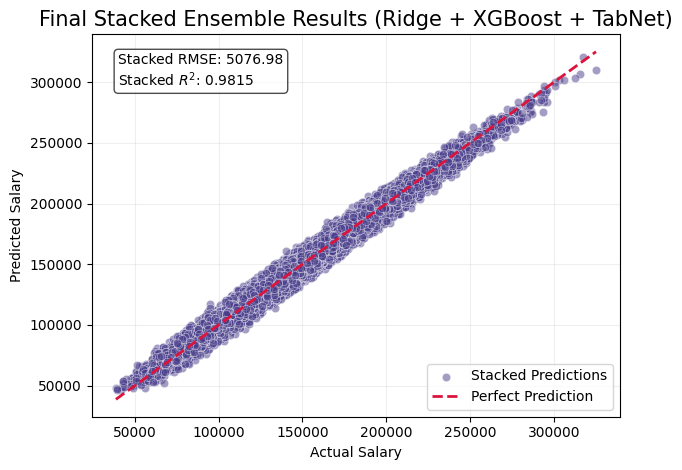

In [47]:
plt.figure()

# Scatter plot for Actual vs Stacked Predictions
sns.scatterplot(
    x=y_test.values.flatten(),
    y=final_predictions.flatten(),
    alpha=0.5,
    color='darkslateblue',
    label='Stacked Predictions'
)

# Perfect Prediction Line (y=x)
# This represents the ideal scenario where Predicted == Actual
line_coords = [y_test.min(), y_test.max()]
plt.plot(line_coords, line_coords, color='crimson', linestyle='--', lw=2, label='Perfect Prediction')

# Add metrics info box to the plot
# This box provides an immediate summary of the model's accuracy
stats_text = f'Stacked RMSE: {final_rmse:.2f}\nStacked $R^2$: {final_r2:.4f}'
plt.text(0.05, 0.95, stats_text,
         transform=plt.gca().transAxes,
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

plt.title('Final Stacked Ensemble Results (Ridge + XGBoost + TabNet)', fontsize=15)
plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

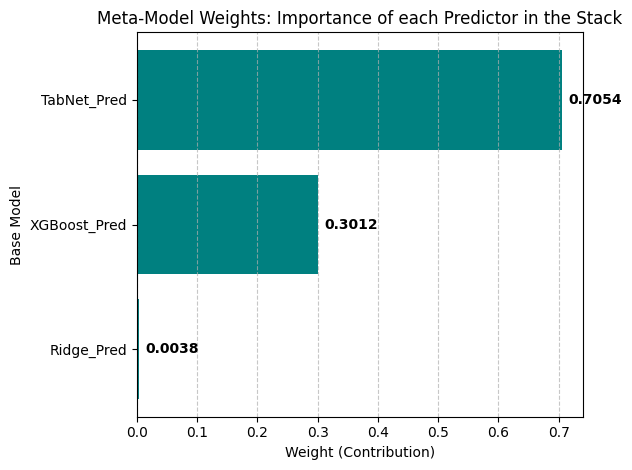

In [48]:
model_weights = pd.DataFrame({
    'Model': meta_columns,
    'Weight': meta_model.coef_.flatten()
})
model_weights = model_weights.sort_values(by='Weight', ascending=True)

plt.figure()
plt.barh(model_weights['Model'], model_weights['Weight'], color='teal')

plt.xlabel("Weight (Contribution)")
plt.ylabel("Base Model")
plt.title("Meta-Model Weights: Importance of each Predictor in the Stack")
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add value labels to the end of each bar for clarity
for i, v in enumerate(model_weights['Weight']):
    plt.text(v + 0.01, i, f"{v:.4f}", color='black', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

## Final Evaluation

In [49]:
comparison_data = {
    'Model': ['Ridge', 'XGBoost', 'TabNet', 'Stacking'],
    'RMSE': [rmse_ridge, xgb_rmse, rmse_recalculated, final_rmse],
    'R2 Score': [r2_ridge, xgb_r2, r2_recalculated, final_r2]
}
df_comparison = pd.DataFrame(comparison_data).sort_values(by='RMSE', ascending=False)

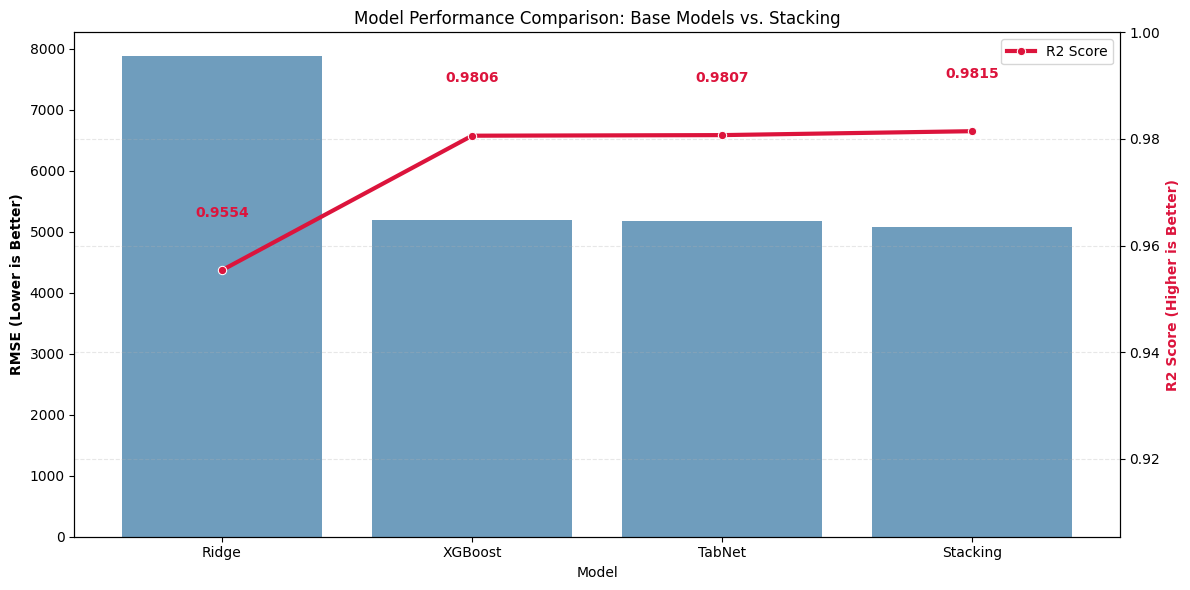

In [50]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot RMSE (Bar Chart) - Lower is Better
sns.barplot(data=df_comparison, x='Model', y='RMSE', ax=ax1, alpha=0.7)
ax1.set_ylabel('RMSE (Lower is Better)', fontweight='bold')
ax1.set_title('Model Performance Comparison: Base Models vs. Stacking')

# Create second axis for R2 (Line Chart) - Higher is Better
ax2 = ax1.twinx()
sns.lineplot(data=df_comparison, x='Model', y='R2 Score', marker='o', color='crimson', lw=3, ax=ax2, label='R2 Score')
ax2.set_ylabel('R2 Score (Higher is Better)', color='crimson', fontweight='bold')
ax2.set_ylim(df_comparison['R2 Score'].min() - 0.05, 1.0) # Adjust scale for clarity
for i, row in df_comparison.reset_index(drop=True).iterrows():
    ax2.text(
        i,
        row['R2 Score'] + 0.01,          # Slightly above the point
        f"{row['R2 Score']:.4f}",        # Format to 4 decimal places
        color='crimson',
        fontweight='bold',
        ha='center'                      # Center horizontally
    )
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

## Simple Demo

In [53]:
def demo():
    """
    Inference function with corrected feature ordering to prevent XGBoost/TabNet mismatches.
    """
    print("--- Salary Estimation Input ---")
    try:
        data = {
            'job_title': [input("Job Title: ")],
            'experience_years': [float(input("Years of Experience: "))],
            'education_level': [input("Education (High School/Diploma/Bachelor/Master/PhD): ")],
            'skills_count': [int(input("Number of Skills: "))],
            'industry': [input("Industry: ")],
            'company_size': [input("Company Size (Startup/Small/Medium/Large/Enterprise): ")],
            'location': [input("Location: ")],
            'remote_work': [input("Remote Work (Yes/No/Hybrid): ")],
            'certifications': [int(input("Number of Certifications: "))]
        }
    except ValueError:
        print("Error: Numeric values required for years, skills, and certifications.")
        return

    df_raw = pd.DataFrame(data)

    # 1. Shared Numerical & Ordinal Preprocessing
    num_cols = ['experience_years', 'skills_count', 'certifications']
    ord_cols = ['education_level', 'company_size']
    cat_cols = ['job_title', 'industry', 'location', 'remote_work']

    df_processed = df_raw.copy()
    df_processed[num_cols] = scaler.transform(df_raw[num_cols])
    df_processed[ord_cols] = ord_enc.transform(df_raw[ord_cols])

    # 2. VERSION A: Ridge (One-Hot Alignment)
    df_ridge = pd.get_dummies(df_processed, columns=cat_cols)
    # Using global X_train_ridge columns to align one-hot features
    df_ridge = df_ridge.reindex(columns=X_train_ridge.columns, fill_value=0)

    # 3. VERSION B: XGBoost/TabNet (Label Encoding)
    df_xgtab = df_processed.copy()
    for col in cat_cols:
        le = label_encoders[col]
        df_xgtab[col] = df_xgtab[col].map(lambda s: s if s in le.classes_ else le.classes_[0])
        df_xgtab[col] = le.transform(df_xgtab[col])

    df_xgtab = df_xgtab[X_train_xgtab.columns]

    # 4. Generate "Opinions" (Base Predictions)
    p_ridge = ridge_model.predict(df_ridge).flatten()
    p_xgb = best_xgb.predict(df_xgtab).flatten()
    p_tabnet = best_tabnet.predict(df_xgtab.values).flatten()

    # 5. Final Blend via Meta-Model
    X_meta = pd.DataFrame(
        np.column_stack([p_ridge, p_xgb, p_tabnet]),
        columns=meta_model.feature_names_in_
    )
    final_salary = meta_model.predict(X_meta)[0]

    # 6. Output Results
    rmse = 5076.98

    print(f"\n" + "="*35)
    print(f"   SALARY PREDICTION RESULTS   ")
    print("="*35)
    print(f"Predicted Salary: ${final_salary:,.2f}")
    print(f"95% Confidence:   ${final_salary - (1.96 * rmse):,.2f} - ${final_salary + (1.96 * rmse):,.2f}")
    print(f"Standard Error:   ${final_salary - rmse:,.2f} - ${final_salary + rmse:,.2f}")
    print("="*35)

demo()

--- Salary Estimation Input ---
Job Title: Backend Developer
Years of Experience: 3
Education (High School/Diploma/Bachelor/Master/PhD): Diploma
Number of Skills: 3
Industry: Healthcare
Company Size (Startup/Small/Medium/Large/Enterprise): Medium
Location: Singapore
Remote Work (Yes/No/Hybrid): Yes
Number of Certifications: 2

   SALARY PREDICTION RESULTS   
Predicted Salary: $99,939.64
95% Confidence:   $89,988.76 - $109,890.52
Standard Error:   $94,862.66 - $105,016.62


Job Title: Backend Developer

Years of Experience: 3

Education (High School/Diploma/Bachelor/Master/PhD): Diploma

Number of Skills: 3

Industry: Healthcare

Company Size (Startup/Small/Medium/Large/Enterprise): Medium

Location: Singapore

Remote Work (Yes/No/Hybrid): Yes

Number of Certifications: 2

----

Predicted Salary: $99,939.64

95% Confidence:   $89,988.76 - $109,890.52

Standard Error:   $94,862.66 - $105,016.62

In [52]:
df[df["location"]=="Canada"].sample(5)

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
215497,DevOps Engineer,6,High School,8,Retail,Medium,Canada,Yes,1,147415
187366,Business Analyst,15,Master,16,Education,Enterprise,Canada,No,1,199452
43501,Cloud Engineer,12,Diploma,11,Consulting,Medium,Canada,No,4,165573
193839,Frontend Developer,18,Diploma,17,Consulting,Enterprise,Canada,Hybrid,3,207148
82994,Data Scientist,20,High School,16,Media,Large,Canada,Yes,1,202092
